In [4]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Set style for plots
sns.set_style('whitegrid')
%matplotlib inline

In [5]:
#  dataset
dataset = pd.read_csv('C:/Users/korup/OneDrive/Desktop/mediConnect/backend/data/cleaned_dataset.csv')
symptom_description = pd.read_csv('C:/Users/korup/OneDrive/Desktop/mediConnect/backend/data/symptom_Description.csv')
symptom_precaution = pd.read_csv('C:/Users/korup/OneDrive/Desktop/mediConnect/backend/data/symptom_precaution.csv')
symptom_severity = pd.read_csv('C:/Users/korup/OneDrive/Desktop/mediConnect/backend/data/Symptom-severity.csv')

# Display the first few rows of each dataset
print("Main Dataset:")
display(dataset.head())

print("\nSymptom Description:")
display(symptom_description.head())

print("\nSymptom Precaution:")
display(symptom_precaution.head())

print("\nSymptom Severity:")
display(symptom_severity.head())

Main Dataset:


,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,...,weight_Symptom_10,weight_Symptom_11,weight_Symptom_12,weight_Symptom_13,weight_Symptom_14,weight_Symptom_15,weight_Symptom_16,weight_Symptom_17,Total_Severity,Disease_Encoded
0,fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,headache,nausea,abdominal_pain,abdominal_pain,yellowing_of_eyes,...,4,2,6,6,7,7,5,2,67.0,15
1,fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,high_fever,headache,nausea,abdominal_pain,abdominal_pain,yellowing_of_eyes,...,4,2,6,6,7,7,5,2,73.0,15
2,fungal infection,itching,nodal_skin_eruptions,dischromic _patches,high_fever,headache,nausea,abdominal_pain,abdominal_pain,yellowing_of_eyes,...,4,2,6,6,7,7,5,2,71.0,15
3,fungal infection,itching,skin_rash,dischromic _patches,high_fever,headache,nausea,abdominal_pain,abdominal_pain,yellowing_of_eyes,...,4,2,6,6,7,7,5,2,70.0,15
4,fungal infection,itching,skin_rash,nodal_skin_eruptions,high_fever,headache,nausea,abdominal_pain,abdominal_pain,yellowing_of_eyes,...,4,2,6,6,7,7,5,2,74.0,15



Symptom Description:


,Disease,Description
0,Drug Reaction,An adverse drug reaction (ADR) is an injury ca...
1,Malaria,An infectious disease caused by protozoan para...
2,Allergy,An allergy is an immune system response to a f...
3,Hypothyroidism,"Hypothyroidism, also called underactive thyroi..."
4,Psoriasis,Psoriasis is a common skin disorder that forms...



Symptom Precaution:


,Disease,Precaution_1,Precaution_2,Precaution_3,Precaution_4
0,Drug Reaction,stop irritation,consult nearest hospital,stop taking drug,follow up
1,Malaria,Consult nearest hospital,avoid oily food,avoid non veg food,keep mosquitos out
2,Allergy,apply calamine,cover area with bandage,NaN,use ice to compress itching
3,Hypothyroidism,reduce stress,exercise,eat healthy,get proper sleep
4,Psoriasis,wash hands with warm soapy water,stop bleeding using pressure,consult doctor,salt baths



Symptom Severity:


,Symptom,weight
0,itching,1
1,skin_rash,3
2,nodal_skin_eruptions,4
3,continuous_sneezing,4
4,shivering,5


In [6]:
# Check basic info for each dataset
def explore_dataset(df, name):
    print(f"\n{name} Information:")
    print(f"Shape: {df.shape}")
    print("\nData Types:")
    print(df.dtypes)
    print("\nMissing Values:")
    print(df.isnull().sum())
    print("\nDescriptive Statistics:")
    display(df.describe(include='all'))

explore_dataset(dataset, "Main Dataset")
explore_dataset(symptom_description, "Symptom Description")
explore_dataset(symptom_precaution, "Symptom Precaution")
explore_dataset(symptom_severity, "Symptom Severity")


Main Dataset Information:
Shape: (309, 37)

Data Types:
Disease               object
Symptom_1             object
Symptom_2             object
Symptom_3             object
Symptom_4             object
Symptom_5             object
Symptom_6             object
Symptom_7             object
Symptom_8             object
Symptom_9             object
Symptom_10            object
Symptom_11            object
Symptom_12            object
Symptom_13            object
Symptom_14            object
Symptom_15            object
Symptom_16            object
Symptom_17            object
weight                 int64
weight_Symptom_2     float64
weight_Symptom_3     float64
weight_Symptom_4     float64
weight_Symptom_5     float64
weight_Symptom_6       int64
weight_Symptom_7       int64
weight_Symptom_8       int64
weight_Symptom_9       int64
weight_Symptom_10      int64
weight_Symptom_11      int64
weight_Symptom_12      int64
weight_Symptom_13      int64
weight_Symptom_14      int64
weight_Symptom_

,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,...,weight_Symptom_10,weight_Symptom_11,weight_Symptom_12,weight_Symptom_13,weight_Symptom_14,weight_Symptom_15,weight_Symptom_16,weight_Symptom_17,Total_Severity,Disease_Encoded
count,309,309,309,309,309,309,309,309,309,309,...,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.0,309.000000,309.000000
unique,41,34,48,54,50,38,32,26,21,22,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,alcoholic hepatitis,vomiting,vomiting,fatigue,high_fever,headache,nausea,abdominal_pain,abdominal_pain,yellowing_of_eyes,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,15,52,54,44,62,94,138,174,183,206,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.996764,2.498382,5.847896,5.841424,6.974110,6.844660,4.915858,2.0,76.245955,20.181230
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.762337,1.247399,0.706765,0.606324,0.277938,0.703755,0.489541,0.0,3.728317,11.792834
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,2.000000,2.0,66.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.000000,2.000000,6.000000,6.000000,7.000000,7.000000,5.000000,2.0,74.000000,10.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.000000,2.000000,6.000000,6.000000,7.000000,7.000000,5.000000,2.0,76.000000,21.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.000000,2.000000,6.000000,6.000000,7.000000,7.000000,5.000000,2.0,79.000000,30.000000



Symptom Description Information:
Shape: (41, 2)

Data Types:
Disease        object
Description    object
dtype: object

Missing Values:
Disease        0
Description    0
dtype: int64

Descriptive Statistics:


,Disease,Description
count,41,41
unique,41,41
top,Drug Reaction,An adverse drug reaction (ADR) is an injury ca...
freq,1,1



Symptom Precaution Information:
Shape: (41, 5)

Data Types:
Disease         object
Precaution_1    object
Precaution_2    object
Precaution_3    object
Precaution_4    object
dtype: object

Missing Values:
Disease         0
Precaution_1    0
Precaution_2    0
Precaution_3    1
Precaution_4    1
dtype: int64

Descriptive Statistics:


,Disease,Precaution_1,Precaution_2,Precaution_3,Precaution_4
count,41,41,41,40,40
unique,41,32,34,30,24
top,Drug Reaction,Consult nearest hospital,exercise,consult doctor,follow up
freq,1,3,3,6,6



Symptom Severity Information:
Shape: (133, 2)

Data Types:
Symptom    object
weight      int64
dtype: object

Missing Values:
Symptom    0
weight     0
dtype: int64

Descriptive Statistics:


,Symptom,weight
count,133,133.000000
unique,132,NaN
top,fluid_overload,NaN
freq,2,NaN
mean,NaN,4.225564
std,NaN,1.323543
min,NaN,1.000000
25%,NaN,3.000000
50%,NaN,4.000000
75%,NaN,5.000000


In [7]:
# Handle missing values in the main dataset
# Fill numerical columns with median and categorical with mode
for col in dataset.columns:
    if dataset[col].dtype == 'object':
        dataset[col].fillna(dataset[col].mode()[0], inplace=True)
    else:
        dataset[col].fillna(dataset[col].median(), inplace=True)

# Verify no missing values remain
print("Missing values after treatment:")
print(dataset.isnull().sum())

Missing values after treatment:
Disease              0
Symptom_1            0
Symptom_2            0
Symptom_3            0
Symptom_4            0
Symptom_5            0
Symptom_6            0
Symptom_7            0
Symptom_8            0
Symptom_9            0
Symptom_10           0
Symptom_11           0
Symptom_12           0
Symptom_13           0
Symptom_14           0
Symptom_15           0
Symptom_16           0
Symptom_17           0
weight               0
weight_Symptom_2     0
weight_Symptom_3     0
weight_Symptom_4     0
weight_Symptom_5     0
weight_Symptom_6     0
weight_Symptom_7     0
weight_Symptom_8     0
weight_Symptom_9     0
weight_Symptom_10    0
weight_Symptom_11    0
weight_Symptom_12    0
weight_Symptom_13    0
weight_Symptom_14    0
weight_Symptom_15    0
weight_Symptom_16    0
weight_Symptom_17    0
Total_Severity       0
Disease_Encoded      0
dtype: int64


In [8]:
# Clean symptom names (remove extra spaces, standardize formatting)
def clean_symptom_names(df):
    for col in df.columns:
        if df[col].dtype == 'object':
            df[col] = df[col].str.strip().str.lower()
    return df

dataset = clean_symptom_names(dataset)
symptom_severity = clean_symptom_names(symptom_severity)

# Check for duplicates
print("Duplicate rows in main dataset:", dataset.duplicated().sum())

# Remove duplicates if any
dataset.drop_duplicates(inplace=True)

Duplicate rows in main dataset: 0


In [9]:
# # Merge symptom severity with main dataset
# # Assuming symptoms are in columns Symptom1, Symptom2, etc. in the main dataset
# symptom_cols = [col for col in dataset.columns if 'Symptom' in col]

# for col in symptom_cols:
#     dataset = dataset.merge(symptom_severity, how='left', 
#                            left_on=col, right_on='Symptom', 
#                            suffixes=('', f'_{col}'))
#     dataset.drop(columns=['Symptom'], inplace=True)  # Drop duplicate column

# Not needed as the data already added weight_Symptom_2 label in cleaned_dataset.csv

# Calculate total severity score
severity_cols = [col for col in dataset.columns if 'weight' in col]
dataset['Total_Severity'] = dataset[severity_cols].sum(axis=1)

In [10]:

# Encode disease names (target variable)
label_encoder = LabelEncoder()
dataset['Disease_Encoded'] = label_encoder.fit_transform(dataset['Disease'])

# One-hot encode symptoms if needed
# symptom_dummies = pd.get_dummies(dataset[symptom_cols].stack()).groupby(level=0).sum()
# dataset = pd.concat([dataset, symptom_dummies], axis=1)

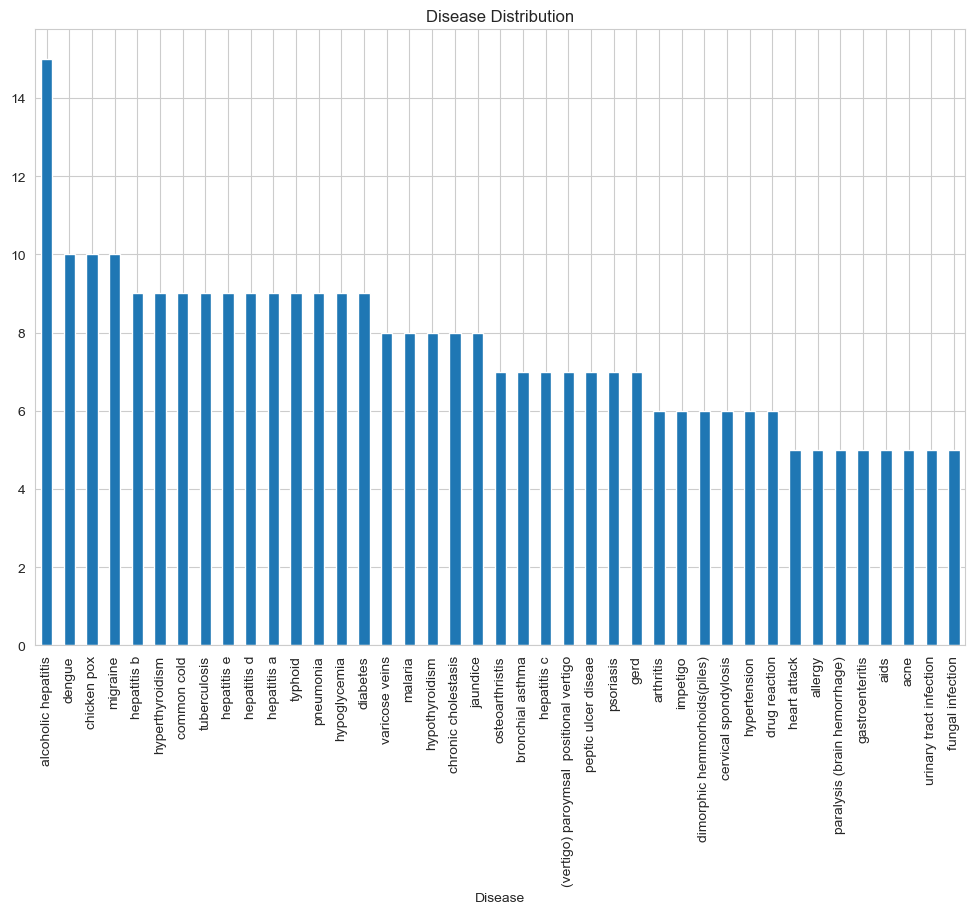

c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


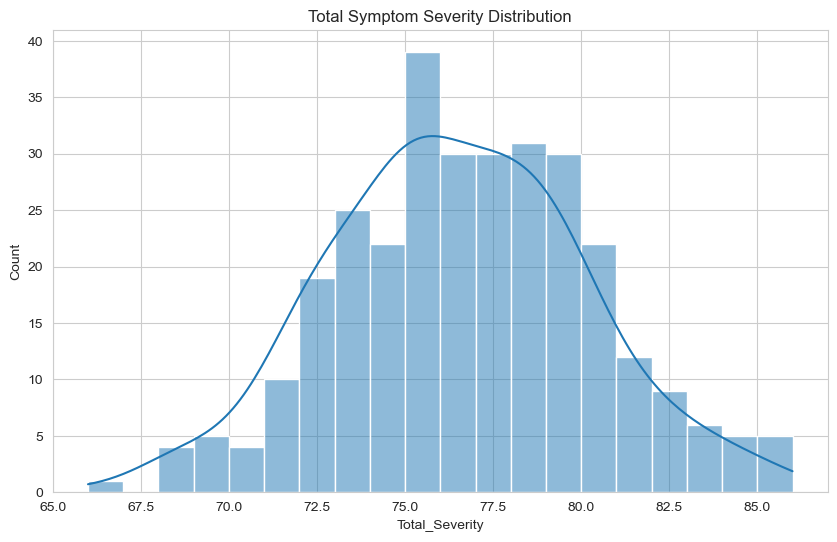

In [11]:
# Disease distribution
plt.figure(figsize=(12, 8))
dataset['Disease'].value_counts().plot(kind='bar')
plt.title('Disease Distribution')
plt.xticks(rotation=90)
plt.show()

# Symptom severity distribution
plt.figure(figsize=(10, 6))
sns.histplot(dataset['Total_Severity'], bins=20, kde=True)
plt.title('Total Symptom Severity Distribution')
plt.show()

In [12]:
# Assuming 'Disease_Encoded' is our target variable
X = dataset.drop(columns=['Disease', 'Disease_Encoded'])
y = dataset['Disease_Encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 247
Testing set size: 62


In [13]:
# Save cleaned and processed datasets
# dataset.to_csv('cleaned_dataset.csv', index=False)
# X_train.to_csv('X_train.csv', index=False)
# X_test.to_csv('X_test.csv', index=False)
# y_train.to_csv('y_train.csv', index=False)
# y_test.to_csv('y_test.csv', index=False)

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [15]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# Load data
df = pd.read_csv('C:/Users/korup/OneDrive/Desktop/mediConnect/backend/data/cleaned_dataset.csv')

# Check for missing values
print("Missing values before treatment:")
print(df.isnull().sum())

# Handle missing values - fill with most frequent for categorical, median for numerical
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

# Convert symptoms to numerical values
for col in df.columns:
    if df[col].dtype == 'object' and col != 'Disease':
        df[col] = df[col].astype('category').cat.codes

# Encode target variable
le = LabelEncoder()
df['Disease'] = le.fit_transform(df['Disease'])

# Verify no missing values remain
print("\nMissing values after treatment:")
print(df.isnull().sum())

# Split data
X = df.drop('Disease', axis=1)
y = df['Disease']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale data (for models that need it)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Missing values before treatment:
Disease              0
Symptom_1            0
Symptom_2            0
Symptom_3            0
Symptom_4            0
Symptom_5            0
Symptom_6            0
Symptom_7            0
Symptom_8            0
Symptom_9            0
Symptom_10           0
Symptom_11           0
Symptom_12           0
Symptom_13           0
Symptom_14           0
Symptom_15           0
Symptom_16           0
Symptom_17           0
weight               0
weight_Symptom_2     2
weight_Symptom_3     5
weight_Symptom_4     5
weight_Symptom_5     1
weight_Symptom_6     0
weight_Symptom_7     0
weight_Symptom_8     0
weight_Symptom_9     0
weight_Symptom_10    0
weight_Symptom_11    0
weight_Symptom_12    0
weight_Symptom_13    0
weight_Symptom_14    0
weight_Symptom_15    0
weight_Symptom_16    0
weight_Symptom_17    0
Total_Severity       0
Disease_Encoded      0
dtype: int64

Missing values after treatment:
Disease              0
Symptom_1            0
Symptom_2            0
S

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Train
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

# Evaluate
y_pred = lr.predict(X_test_scaled)
print("\nLogistic Regression Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Logistic Regression Results:
Accuracy: 0.8387096774193549
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         3
           4       1.00      0.33      0.50         3
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         3
           7       0.33      0.50      0.40         2
           8       1.00      1.00      1.00         3
           9       0.00      0.00      0.00         2
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         1
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         2
          14       0.00      0.00      0.00         1
          15       0.50      1.00      0.67         1
          16       0.0

C:\Users\korup\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\korup\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\korup\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(

In [17]:
from sklearn.ensemble import RandomForestClassifier

# Train (no scaling needed)
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

# Evaluate
y_pred = rf.predict(X_test)
print("\nRandom Forest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Feature importance
importances = rf.feature_importances_
print("\nTop 5 Important Features:")
for i in np.argsort(importances)[-5:]:
    print(f"{X.columns[i]}: {importances[i]:.4f}")


Random Forest Results:
Accuracy: 0.967741935483871


C:\Users\korup\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\korup\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         3
           4       1.00      0.67      0.80         3
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         3
           7       1.00      1.00      1.00         2
           8       1.00      1.00      1.00         3
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         1
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         2
          14       0.50      1.00      0.67         1
          15       1.00      1.00      1.00         1
          18       1.00      1.00      1.00         1
          19       1.00    

C:\Users\korup\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [18]:

from sklearn.svm import SVC

# Train
svm = SVC(kernel='linear')
svm.fit(X_train_scaled, y_train)

# Evaluate
y_pred = svm.predict(X_test_scaled)
print("\nSVM Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


SVM Results:
Accuracy: 0.8548387096774194
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      0.67      0.80         3
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         3
           4       1.00      0.33      0.50         3
           5       1.00      1.00      1.00         1
           6       1.00      0.67      0.80         3
           7       0.67      1.00      0.80         2
           8       1.00      1.00      1.00         3
           9       0.00      0.00      0.00         2
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         1
          12       1.00      1.00      1.00         2
          13       0.50      1.00      0.67         2
          14       1.00      1.00      1.00         1
          15       0.50      1.00      0.67         1
          16       0.00      0.00     

C:\Users\korup\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\korup\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\korup\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(

In [19]:
from sklearn.neighbors import KNeighborsClassifier

# Train
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Evaluate
y_pred = knn.predict(X_test_scaled)
print("\nk-NN Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


k-NN Results:
Accuracy: 0.8548387096774194
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      0.67      0.80         3
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         3
           4       1.00      0.33      0.50         3
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         3
           7       0.67      1.00      0.80         2
           8       1.00      1.00      1.00         3
           9       0.00      0.00      0.00         2
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         1
          12       1.00      1.00      1.00         2
          13       0.67      1.00      0.80         2
          14       0.00      0.00      0.00         1
          15       0.50      1.00      0.67         1
          16       0.00      0.00    

C:\Users\korup\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\korup\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\korup\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(

In [20]:
# # In your training notebook, after training the model:
# import joblib
# import json

# # Save model and feature names
# joblib.dump(rf, 'disease_predictor_rf.pkl')
# joblib.dump(scaler, 'scaler.pkl')
# joblib.dump(le, 'label_encoder.pkl')

# # Save the feature names (columns) that the model expects
# with open('feature_names.json', 'w') as f:
#     json.dump(list(X_train.columns), f)  # X_train from your training code

In [21]:
# Cell 1: Create a function to test the Random Forest model with new inputs
def predict_with_rf(symptoms_dict):
    """
    Predict disease using the trained Random Forest model.
    
    Parameters:
    symptoms_dict: Dictionary with symptom names as keys and values (0 or 1 for presence)
                   Example: {'Symptom_1': 1, 'Symptom_2': 1, 'Symptom_3': 1}
    """
    # Create a dataframe with zeros for all features
    test_df = pd.DataFrame(0, index=[0], columns=X_train.columns)
    
    # Fill in the symptoms from the dictionary
    for symptom, value in symptoms_dict.items():
        if symptom in test_df.columns:
            test_df.loc[0, symptom] = value
    
    # Make prediction
    prediction_encoded = rf.predict(test_df)[0]
    disease_name = le.inverse_transform([prediction_encoded])[0]
    
    # Get probabilities
    probabilities = rf.predict_proba(test_df)[0]
    top_3_idx = probabilities.argsort()[-3:][::-1]
    
    print(f"Predicted Disease: {disease_name}")
    print(f"Confidence: {probabilities[prediction_encoded]:.2%}")
    
    print("\nTop 3 predictions:")
    for idx in top_3_idx:
        disease = le.inverse_transform([idx])[0]
        prob = probabilities[idx]
        print(f"  - {disease}: {prob:.2%}")
    
    return disease_name

# Test with some symptoms
print("Test 1: Random symptoms")
test_symptoms = {'Symptom_1': 1, 'Symptom_2': 1, 'Symptom_3': 1, 'Total_Severity': 5}
predict_with_rf(test_symptoms)

Test 1: Random symptoms
Predicted Disease: dengue
Confidence: 24.00%

Top 3 predictions:
  - dengue: 24.00%
  - hyperthyroidism: 20.00%
  - hypoglycemia: 10.00%


'dengue'

In [22]:
# Cell 2: Test with actual symptom names from your dataset
# Let's see what symptoms we have
print("Available symptom columns (first 15):")
for i, col in enumerate(X_train.columns[:15]):
    print(f"{i+1}. {col}")

print(f"\nTotal number of features: {len(X_train.columns)}")

Available symptom columns (first 15):
1. Symptom_1
2. Symptom_2
3. Symptom_3
4. Symptom_4
5. Symptom_5
6. Symptom_6
7. Symptom_7
8. Symptom_8
9. Symptom_9
10. Symptom_10
11. Symptom_11
12. Symptom_12
13. Symptom_13
14. Symptom_14
15. Symptom_15

Total number of features: 36


In [23]:
# Cell 3: Create a more realistic test
def predict_with_actual_symptoms():
    """Interactive test with actual symptoms from the dataset"""
    print("Available symptom features:")
    symptom_cols = [col for col in X_train.columns if 'Symptom' in col]
    for i, col in enumerate(symptom_cols[:20]):
        print(f"{col}")
    
    print("\nExample: Testing with Symptom_1, Symptom_2, Symptom_3")
    test_input = {
        'Symptom_1': 1,
        'Symptom_2': 1,
        'Symptom_3': 1,
        'weight': 2,
        'Total_Severity': 7
    }
    
    return predict_with_rf(test_input)

# Run the test
predict_with_actual_symptoms()

Available symptom features:
Symptom_1
Symptom_2
Symptom_3
Symptom_4
Symptom_5
Symptom_6
Symptom_7
Symptom_8
Symptom_9
Symptom_10
Symptom_11
Symptom_12
Symptom_13
Symptom_14
Symptom_15
Symptom_16
Symptom_17
weight_Symptom_2
weight_Symptom_3
weight_Symptom_4

Example: Testing with Symptom_1, Symptom_2, Symptom_3
Predicted Disease: dengue
Confidence: 24.00%

Top 3 predictions:
  - dengue: 24.00%
  - hyperthyroidism: 21.00%
  - hypoglycemia: 10.00%


'dengue'

In [24]:
# Cell 4: Test multiple models comparison
def compare_models(symptoms_dict):
    """Compare predictions from all trained models"""
    # Prepare input
    test_df = pd.DataFrame(0, index=[0], columns=X_train.columns)
    for symptom, value in symptoms_dict.items():
        if symptom in test_df.columns:
            test_df.loc[0, symptom] = value
    
    # Scale for models that need it
    test_scaled = scaler.transform(test_df)
    
    print("Model Comparison Results:")
    print("=" * 50)
    
    models = {
        'Logistic Regression': lr,
        'Random Forest': rf,
        'SVM': svm,
        'k-NN': knn
    }
    
    results = {}
    for name, model in models.items():
        if name in ['Logistic Regression', 'SVM', 'k-NN']:
            pred = model.predict(test_scaled)[0]
        else:
            pred = model.predict(test_df)[0]
        
        disease = le.inverse_transform([pred])[0]
        results[name] = disease
        
        if name == 'Random Forest':
            prob = model.predict_proba(test_df)[0][pred]
            print(f"{name}: {disease} (Confidence: {prob:.2%})")
        else:
            print(f"{name}: {disease}")
    
    return results

# Test with some symptoms
test_symptoms = {
    'Symptom_1': 1,
    'Symptom_2': 1,
    'Symptom_4': 1,
    'Total_Severity': 6,
    'Disease_Encoded': 0
}

results = compare_models(test_symptoms)

Model Comparison Results:
Logistic Regression: psoriasis
Random Forest: dengue (Confidence: 22.00%)
SVM: dengue
k-NN: dengue


In [25]:
# Cell 5: Test on actual samples from the test set
print("Testing on actual test samples:")
print("=" * 50)

# Take first 3 samples from test set
for i in range(3):
    print(f"\nTest Sample {i+1}:")
    print(f"Actual Disease: {le.inverse_transform([y_test.iloc[i]])[0]}")
    
    # Get the features for this sample
    sample_features = X_test.iloc[i:i+1]
    
    # Predict with Random Forest
    rf_pred = rf.predict(sample_features)[0]
    rf_disease = le.inverse_transform([rf_pred])[0]
    rf_prob = rf.predict_proba(sample_features)[0][rf_pred]
    
    print(f"RF Prediction: {rf_disease} (Confidence: {rf_prob:.2%})")
    
    # Check if correct
    if rf_pred == y_test.iloc[i]:
        print("✓ Correct!")
    else:
        print("✗ Incorrect")

Testing on actual test samples:

Test Sample 1:
Actual Disease: acne
RF Prediction: acne (Confidence: 64.00%)
✓ Correct!

Test Sample 2:
Actual Disease: allergy
RF Prediction: allergy (Confidence: 21.00%)
✓ Correct!

Test Sample 3:
Actual Disease: bronchial asthma
RF Prediction: bronchial asthma (Confidence: 40.00%)
✓ Correct!


In [26]:
# Cell 6: Create a complete test function
def test_new_patient(symptom_list, severity_weights=None):
    """
    Test a new patient with given symptoms
    
    Parameters:
    symptom_list: List of symptom indices (1-17)
    severity_weights: Optional dictionary of severity weights for each symptom
    """
    # Create default input
    test_input = {}
    
    # Add symptoms
    for i in range(1, 18):
        symptom_name = f'Symptom_{i}'
        if i in symptom_list:
            test_input[symptom_name] = 1
        else:
            test_input[symptom_name] = 0
    
    # Add severity weights if provided
    if severity_weights:
        for symptom_idx, weight in severity_weights.items():
            weight_name = f'weight_Symptom_{symptom_idx}'
            test_input[weight_name] = weight
    
    # Calculate total severity
    total_severity = sum(severity_weights.values()) if severity_weights else len(symptom_list)
    test_input['Total_Severity'] = total_severity
    
    # Add other features
    test_input['weight'] = len(symptom_list)  # Simple weight calculation
    test_input['Disease_Encoded'] = 0  # Default value
    
    print(f"Testing with {len(symptom_list)} symptoms:")
    print(f"Symptoms: {symptom_list}")
    if severity_weights:
        print(f"Severity weights: {severity_weights}")
    print(f"Total Severity: {total_severity}")
    print("-" * 30)
    
    return predict_with_rf(test_input)

# Example test
print("Example 1: Patient with symptoms 1, 3, 5")
test_new_patient([1, 3, 5], {1: 2, 3: 3, 5: 1})

print("\n" + "="*50 + "\n")

print("Example 2: Patient with symptoms 2, 4, 6, 8")
test_new_patient([2, 4, 6, 8])

Example 1: Patient with symptoms 1, 3, 5
Testing with 3 symptoms:
Symptoms: [1, 3, 5]
Severity weights: {1: 2, 3: 3, 5: 1}
Total Severity: 6
------------------------------
Predicted Disease: dengue
Confidence: 24.00%

Top 3 predictions:
  - dengue: 24.00%
  - hyperthyroidism: 22.00%
  - hypoglycemia: 10.00%


Example 2: Patient with symptoms 2, 4, 6, 8
Testing with 4 symptoms:
Symptoms: [2, 4, 6, 8]
Total Severity: 4
------------------------------
Predicted Disease: dengue
Confidence: 22.00%

Top 3 predictions:
  - dengue: 22.00%
  - hyperthyroidism: 21.00%
  - hypoglycemia: 11.00%


'dengue'

In [32]:
# Cell 7: Quick diagnostic tool
def quick_diagnose():
    """Quick interactive diagnosis tool"""
    print("Quick Disease Diagnosis Tool")
    print("Enter the symptoms present (1-17), separated by commas")
    print("Example: 1,3,5,7")
    
    try:
        symptoms_input = input("Symptoms: ")
        symptom_list = [int(s.strip()) for s in symptoms_input.split(',')]
        
        print("\nEnter severity for each symptom (1-5 scale)")
        severity_weights = {}
        for symptom in symptom_list:
            while True:
                try:
                    severity = int(input(f"Severity for Symptom_{symptom} (1-5): "))
                    if 1 <= severity <= 5:
                        severity_weights[symptom] = severity
                        break
                    else:
                        print("Please enter a number between 1 and 5")
                except ValueError:
                    print("Please enter a valid number")
        
        return test_new_patient(symptom_list, severity_weights)
    
    except Exception as e:
        print(f"Error: {e}")
        return None

# Uncomment to run interactive diagnosis
quick_diagnose()

Quick Disease Diagnosis Tool
Enter the symptoms present (1-17), separated by commas
Example: 1,3,5,7

Enter severity for each symptom (1-5 scale)
Please enter a number between 1 and 5
Please enter a number between 1 and 5
Please enter a number between 1 and 5
Please enter a number between 1 and 5
Please enter a number between 1 and 5
Please enter a number between 1 and 5
Testing with 19 symptoms:
Symptoms: [1, 3, 4, 3, 5, 4, 4, 4, 4, 2, 6, 6, 7, 7, 5, 2, 6, 7, 15]
Severity weights: {1: 4, 3: 4, 4: 3, 5: 2, 2: 1, 6: 4, 7: 4, 15: 2}
Total Severity: 24
------------------------------
Predicted Disease: hyperthyroidism
Confidence: 22.00%

Top 3 predictions:
  - hyperthyroidism: 22.00%
  - dengue: 21.00%
  - hypoglycemia: 14.00%


'hyperthyroidism'

In [31]:
# Cell 8: Test with completely random input
import random

def test_random_patient():
    """Test with randomly generated symptoms"""
    # Random number of symptoms (1-8)
    num_symptoms = random.randint(1, 8)
    
    # Random symptoms
    all_symptoms = list(range(1, 18))
    selected_symptoms = random.sample(all_symptoms, num_symptoms)
    
    # Random severities
    severities = {s: random.randint(1, 5) for s in selected_symptoms}
    
    print("Random Patient Test:")
    return test_new_patient(selected_symptoms, severities)

# Run 3 random tests
for i in range(3):
    print(f"\n{'='*60}")
    print(f"RANDOM TEST {i+1}")
    print('='*60)
    test_random_patient()
    print()


RANDOM TEST 1
Random Patient Test:
Testing with 1 symptoms:
Symptoms: [16]
Severity weights: {16: 5}
Total Severity: 5
------------------------------
Predicted Disease: dengue
Confidence: 21.00%

Top 3 predictions:
  - dengue: 21.00%
  - hyperthyroidism: 19.00%
  - hypoglycemia: 11.00%


RANDOM TEST 2
Random Patient Test:
Testing with 3 symptoms:
Symptoms: [8, 16, 15]
Severity weights: {8: 3, 16: 1, 15: 4}
Total Severity: 8
------------------------------
Predicted Disease: dengue
Confidence: 21.00%

Top 3 predictions:
  - dengue: 21.00%
  - hyperthyroidism: 19.00%
  - common cold: 12.00%


RANDOM TEST 3
Random Patient Test:
Testing with 4 symptoms:
Symptoms: [13, 8, 17, 15]
Severity weights: {13: 4, 8: 1, 17: 4, 15: 2}
Total Severity: 11
------------------------------
Predicted Disease: dengue
Confidence: 24.00%

Top 3 predictions:
  - dengue: 24.00%
  - hyperthyroidism: 20.00%
  - hypoglycemia: 10.00%

